In [41]:
from pathlib import Path
from tqdm import tqdm
import json
import shutil
tqdm.pandas()
#
import biotite.sequence as seq
import biotite.sequence.io.fasta as fasta
from biotite.sequence.align import Alignment
import biotite.sequence.graphics as graphics
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import spearmanr, pearsonr, linregress
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

### Sequence filtering

##### Plot

In [6]:
# visualize sequences designed
def plot_seqs(df, structure_name, start=0, show_seqs=5, scheme='zappo'):
    # read df of sequences (not incl input)
    df = df[df['id'].str.contains(structure_name)]

    # "align" (stack) sequences
    alignment = Alignment(
        [
            seq.ProteinSequence(s)
            for s in df['sequence']
        ],
        Alignment.trace_from_strings(list(df['sequence']))
    )

    # plot sequence logo
    profile = seq.SequenceProfile.from_alignment(alignment)
    fig, ax = plt.subplots(figsize=(18, 3))
    graphics.plot_sequence_logo(
        ax,
        profile,
        scheme=scheme
    )
    ax.set_xlabel('residue', fontsize=20, fontweight='bold')
    ax.set_ylabel('bits', fontsize=20, fontweight='bold')
    ax.set_xlim(start, ax.get_xlim()[1])
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    fig.tight_layout()
    plt.show()

    # plot first few sequences
    fig, ax = plt.subplots(figsize=(18, 6))
    graphics.plot_alignment_type_based(
        ax,
        alignment[:, :show_seqs],
        labels=list(df.index[:show_seqs]),
        show_numbers=True,
        color_scheme=scheme,
        color_symbols=True,
        symbols_per_line=int(len(df.iloc[0, 1]) / 2), #type: ignore
        symbol_size = 24,
        spacing = 1
    )
    fig.tight_layout()
    plt.show()

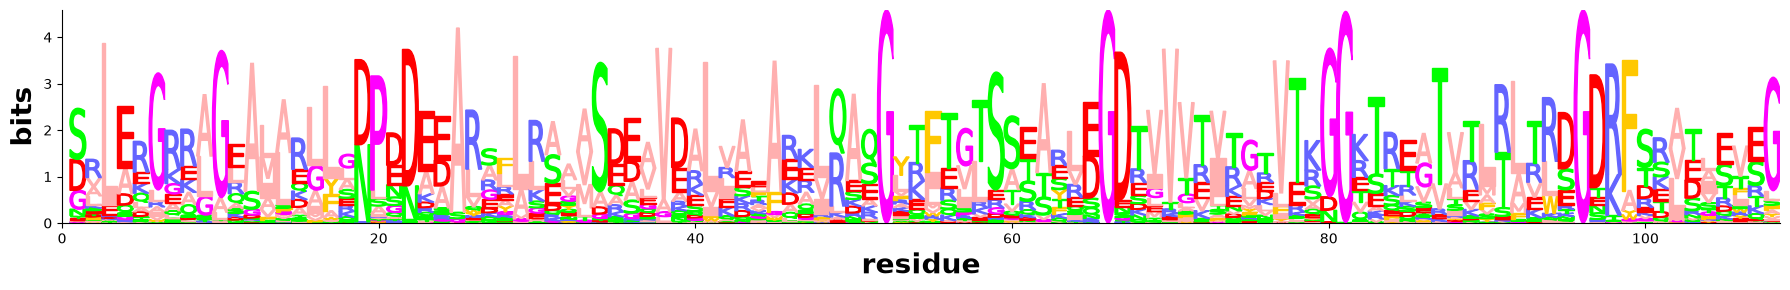

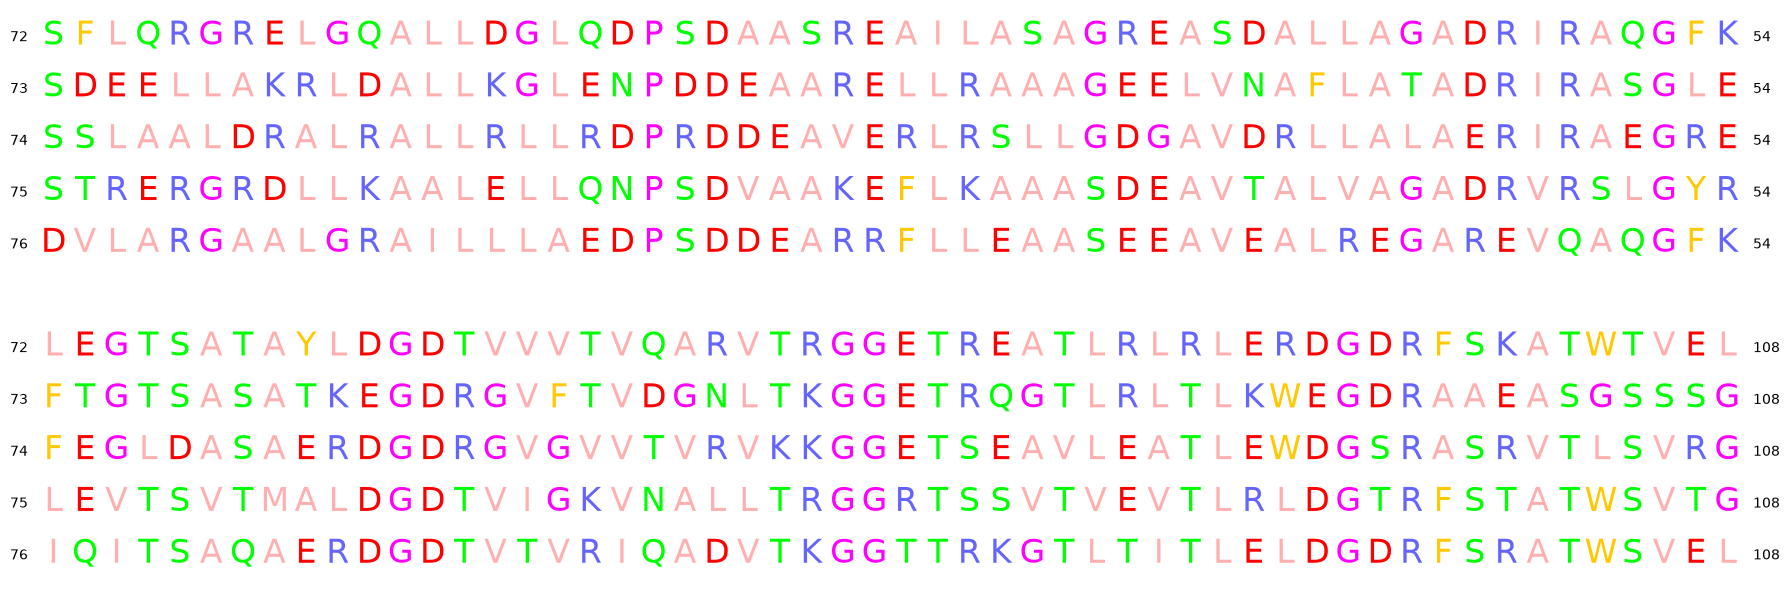

In [35]:
plot_seqs(dfs['0.3'], '5KPE')

##### Filter

In [31]:
# read in sequences
dfs = {
    '0.1': pd.read_csv(f'/wynton/home/rotation/geanhu/multi-state/data/mpnn-output/5KPE-5KPH_multi-state/temp1/seqs/seqs.csv'),
    '0.2': pd.read_csv(f'/wynton/home/rotation/geanhu/multi-state/data/mpnn-output/5KPE-5KPH_multi-state/temp2/seqs/seqs.csv'),
    '0.3': pd.read_csv(f'/wynton/home/rotation/geanhu/multi-state/data/mpnn-output/5KPE-5KPH_multi-state/temp3/seqs/seqs.csv')
}

In [24]:
# re-organize Caliby outputs dfs
for temp in dfs:
    df = dfs[temp].copy()
    df['id'] = df.apply(
        lambda row: f'{row['example_id'][:-2]}_id{row['out_pdb'].split('_sample')[1].split('.')[0]}',
        axis=1
    ) #type: ignore
    df['sequence'] = df['seq']
    df = df[['id', 'sequence']]
    dfs[temp] = df.copy()

In [32]:
# filter out runs
def longest_run(input):
    prev_char = None
    longest_run = 0
    current_run = 0

    for character in input:
        if character == prev_char:
            current_run += 1
        else:
            current_run = 0
            prev_char = character
        #
        if current_run > longest_run:
            longest_run = current_run
    #
    return longest_run

max_run = 4
def filter_runs(sequence):
    return longest_run(sequence) < max_run

for temp in dfs:
    # filter out sequences
    mask = dfs[temp]['sequence'].apply(filter_runs)
    filtered_df = dfs[temp][mask]

    # report stats
    print(f'For temp {temp}, {len(filtered_df)} of {len(dfs[temp])} remain')

    # keep filtered
    dfs[temp] = filtered_df.copy()

For temp 0.1, 3907 of 4128 remain
For temp 0.2, 3935 of 4128 remain
For temp 0.3, 3974 of 4128 remain


In [36]:
max_comp = 0.25
enriched_aas = []
def filter_lcp(sequence):
    sequence_array = np.array(list(sequence))
    aas, counts = np.unique(sequence_array, return_counts=True)
    comp = np.max(counts) / len(sequence)
    if comp < max_comp:
        return True
    else:
        enriched_aas.append(aas[np.argmax(counts)])
        return False

for temp in dfs:
    # filter out sequences
    mask = dfs[temp]['sequence'].apply(filter_lcp) #type:ignore
    filtered_df = dfs[temp][mask]

    # report stats
    print(f'For temp {temp}, {len(filtered_df)} of {len(dfs[temp])} remain')

    # keep filtered
    dfs[temp] = filtered_df.copy()

# print which AAs enriched > threshold
enriched_aa, enriched_count = np.unique(enriched_aas, return_counts=True)
for (aa, count) in zip(enriched_aa, enriched_count):
    print(f'{aa}: {count}')

For temp 0.1, 3855 of 3907 remain
For temp 0.2, 3910 of 3935 remain
For temp 0.3, 3966 of 3974 remain
A: 53
E: 11
K: 1
Q: 3
R: 8
S: 6
T: 3


In [37]:
# check # of unique backbones remaining
def backbone(name):
    return '_'.join(name.split('_')[:4]) #5

backbones_original = []
for temp in dfs:
    backbones = dfs[temp]['id'].apply(backbone)
    backbones_original.append(np.unique(backbones))

for backbones in backbones_original:
    print(len(backbones))

172
172
172


In [38]:
# duplicate sequences
for temp in dfs:
    pre_count = len(dfs[temp])
    dfs[temp] = dfs[temp].sort_values(by='id')
    dfs[temp] = dfs[temp].drop_duplicates(
        subset=['sequence'],
        keep = 'last'
    )
    post_count = len(dfs[temp])
    print(f'Dropped {post_count - pre_count} duplicate sequences')

Dropped 0 duplicate sequences
Dropped 0 duplicate sequences
Dropped 0 duplicate sequences


In [39]:
# save filtered dfs
for temp in dfs:
    save_path = f'/wynton/home/rotation/geanhu/multi-state/data/mpnn-output/5KPE-5KPH_multi-state/temp{temp[-1]}/filtered_seqs.csv'
    dfs[temp].to_csv(save_path, index=False)

print(dfs[temp].loc[0, 'sequence'])

SEEEEKEQAAKLALAGLQKQFPDATATLLSLEVDGDMVTITVELKQDGKTGKFKLTLTREGDNVRILSMEKV


### Check AF jobs

In [22]:
input_folder = '/wynton/home/rotation/geanhu/multi-state/data/caliby-output/5KPE-5KPH/temp10-2'
output_folder = '/wynton/home/rotation/geanhu/multi-state/data/colabfold-output/5KPE-5KPH_caliby_multi-state/temp10-2'

In [23]:
# get intended seqs
input_seqs = pd.read_csv(f'{input_folder}/filtered_seqs.csv')
input_seqs = input_seqs.set_index('id')
input_seqs['count'] = 0

In [24]:
# find number of actual outputs
for item in tqdm(list(Path(output_folder).iterdir())):
    if item.suffix == '.pdb':
        name = item.stem.split('_unrelaxed_')[0]
        input_seqs.loc[name, 'count'] += 1 #type: ignore

100%|████████████| 147963/147963 [00:17<00:00, 8339.48it/s]


In [25]:
# filter sequences with < intended outputs
expected_count = 15
original_count = len(input_seqs)
input_seqs = input_seqs[input_seqs['count'] < expected_count]
print(f'{len(input_seqs)} of {original_count} sequences did not finish')

# save
if len(input_seqs) > 0:
    input_seqs.reset_index()[['id', 'sequence']].to_csv(f'{input_folder}/incomplete-seqs2.csv', index=False)

0 of 4110 sequences did not finish


### Assessing designs

#### Load in data

In [140]:
# load per-structure-prediction metrics
def load_data(
    folder,
    #seq_path
):
    # load in scores
    print('Load Alphafold scores ...')
    df = pd.read_csv(f'{folder}/scores.csv', index_col = 0)

    # load in RMSD scores
    print('Load RMSD to start state ...')
    df['rmsd_start'] = load_rmsd(f'{folder}/rmsd_CA_rmsd_paths_start.json', df)
    print('Load RMSD to end state ...')
    df['rmsd_end'] = load_rmsd(f'{folder}/rmsd_CA_rmsd_paths_end.json', df)

    return df.copy()
    
def load_rmsd(
    jsonpath,
    df
):
    rmsds = np.zeros(len(df))
    rmsds[:] = 10 # set default value to 10 so any error empty predictions do not pass filter

    # open json file
    with open(jsonpath, 'r') as file:
        rmsd_dict = json.load(file)

    for path in tqdm(list(rmsd_dict.keys())):
        # get metadata
        name = Path(path).stem.split('_unrelaxed_')[0]
        seed = int(Path(path).stem.split('_seed_')[1])
        model = int(Path(path).stem.split('_model_')[1].split('_')[0])

        # match row
        row = df[
            (df['name'] == name) &
            (df['seed'] == seed) &
            (df['model'] == model)
        ]
        if len(row) == 0:
            continue #skip samples not predicted

        # store rmsd
        rmsds[row.index[0]] = rmsd_dict[path] #type: ignore

    return rmsds

In [523]:
# load scores
data_path = '/wynton/home/rotation/geanhu/multi-state/data/colabfold-output/5KPE-5KPH_caliby_multi-state/temp10-2'
save_name = '_'.join(data_path.split('/')[-2:])
print(f'Loading {save_name}')
data = load_data(data_path)

Loading 5KPE-5KPH_caliby_multi-state_temp10-2
Load Alphafold scores ...
Load RMSD to start state ...


100%|██████████████████████████| 61650/61650 [01:49<00:00, 562.59it/s]


Load RMSD to end state ...


100%|██████████████████████████| 61650/61650 [01:50<00:00, 558.80it/s]


In [503]:
# load backbone-specific metrics
def load_unique_data(df):
    # RMSD constraint
    df['rmsd_constraint'] = df['name'].apply(
        lambda name: int(name.split('_')[1])
    ) #type: ignore

    # Langevin factor
    df['langevin'] = df['name'].apply(
        lambda name: int(name.split('_')[2])
    ) #type: ignore

    # single state design metrics
    print('Load single state design metrics ...')
    single_state = pd.read_csv('/wynton/home/rotation/geanhu/multi-state/notebooks/single-state-design.csv')
    df[['single_state_plddt', 'single_state_rmsd']] = df.progress_apply(
        lambda row: get_single_state(row['name'], single_state),
        result_type='expand',
        axis = 1
    ) #type: ignore

    # curvature
    backbones = pd.read_csv('/wynton/home/rotation/geanhu/multi-state/notebooks/backbones.csv')
    print('Load curvature scores ...')
    df['curvature_mean'] = df['name'].progress_apply(
        lambda name: backbones[backbones['name'] == '_'.join(name.split('_')[:4])]['mean_c'].values[0] #type: ignore
    ) #type: ignore
    df['curvature_max'] = df['name'].progress_apply(
        lambda name: backbones[backbones['name'] == '_'.join(name.split('_')[:4])]['max_c'].values[0] #type: ignore
    ) #type: ignore

    return df.copy()

def get_single_state(name, single_state, plddt_col='plddt', rmsd_col='rmsd_diffusion'):
    rows = single_state[single_state['name'].str.contains(
        '_'.join(name.split('_')[:4])
    )]
    plddt = np.max(rows[plddt_col])
    rmsd = np.min(rows[rmsd_col])
    return plddt, rmsd

In [524]:
# for each sequence, collapse into min RMSD 
data_unique = data.groupby('name', as_index=False).agg(
    {
        'rmsd_start': 'min',
        'rmsd_end': 'min',
        'plddt': 'max',
        'ptm': 'max'
    }
)

# Load per-backbone metrics
data_unique = load_unique_data(data_unique)

Load single state design metrics ...


  0%|                                        | 0/4110 [00:00<?, ?it/s]

100%|████████████████████████████| 4110/4110 [00:09<00:00, 451.84it/s]


Load curvature scores ...


100%|███████████████████████████| 4110/4110 [00:03<00:00, 1282.26it/s]


In [525]:
data_safe = data_unique.copy()
#data_unique = data_safe.copy()

In [532]:
# sequence specific metrics
def sequence_scores(df, sequence_path, frame2seq_folder=None):

    # Load sequence design scores
    if 'score' not in df.columns:
        if 'mpnn-output' in sequence_path:
            scores = pd.read_csv(f'{sequence_path}/seqs/seqs_scores.csv')
            scores = scores[['id', 'score']] #ignore sequence

            # combine based on sequence name
            df = df.merge(
                scores,
                left_on='name',
                right_on='id',
                how='left',
                validate='one_to_one'
            ).drop(columns='id')
        
        elif 'caliby-output' in sequence_path:
            scores = pd.read_csv(f'{sequence_path}/seq_des_outputs.csv')
            scores['name'] = scores.apply(
                lambda row: f'{'_'.join(row['example_id'].split('_')[:4])}_id{row['out_pdb'].split('_sample')[1].split('.')[0]}',
                axis = 1
            )
            scores = scores[['name', 'U']] #only name and energy score

            # combine
            df = df.merge(
                scores,
                on='name',
                how='left',
                validate='one_to_one'
            )

        else:
            raise ValueError(f'{sequence_path} invalid')

    # frame2seq scores
    if '-PLL' not in df.columns:
        if not frame2seq_folder:
            frame2seq_path = f'/wynton/home/rotation/geanhu/multi-state/data/frame2seq-output/{'/'.join(sequence_path.split('/')[-2:])}/scores.csv'
        else:
            frame2seq_path = str(Path(frame2seq_folder, 'scores.csv'))
        frame2seq_scores = pd.read_csv(frame2seq_path)

        # match naming convention
        if 'mpnn-output' in sequence_path:
            frame2seq_scores['PDBID'] = frame2seq_scores['PDBID'].apply(
                lambda name: '_'.join([name.split('_combined_')[0], 'combined', f'id{name.split('_combined_')[1]}'])
            )
        elif 'caliby-output' in sequence_path:
            frame2seq_scores['PDBID'] = frame2seq_scores['PDBID'].apply(
                lambda name: f'5KPE_2_2_0_{name}' if (not '5KP' in name) else name
            )
            #frame2seq_scores['PDBID'] = frame2seq_scores['PDBID'].apply(
            #    lambda name: '_'.join([name.split('_p0_')[0], 'id' + name.split('sample')[1]])
            #)
            frame2seq_scores['PDBID'] = frame2seq_scores['PDBID'].apply(
                lambda name: name.replace('p0_sample', 'id')          
            )
        
        frame2seq_scores = frame2seq_scores[['PDBID', 'Average negative pseudo-log-likelihood']]
       
        # merge
        df = df.merge(
            frame2seq_scores,
            left_on='name',
            right_on='PDBID',
            how = 'left',
            validate = 'one_to_one'
        ).drop(columns='PDBID')
        df = df.rename(columns={'Average negative pseudo-log-likelihood':'-PLL'})

    return df.copy()

In [533]:
# load sequence scores
seq_path = '/wynton/home/rotation/geanhu/multi-state/data/caliby-output/5KPE-5KPH/temp10-2'
data_unique = sequence_scores(
    data_unique,
    seq_path,
    frame2seq_folder = '/wynton/home/rotation/geanhu/multi-state/data/frame2seq-output/5KPE-5KPH_caliby_multi-state/temp10-2'
)

In [245]:
# load existing data
save_name = '5KPE-5KPH_refined_multi-state3_temp1'
data = pd.read_csv(f'/wynton/home/rotation/geanhu/multi-state/notebooks/data/{save_name}_data.csv')
data_unique = pd.read_csv(f'/wynton/home/rotation/geanhu/multi-state/notebooks/data/{save_name}_data_unique.csv')
seq_path = f'/wynton/home/rotation/geanhu/multi-state/data/mpnn-output/{'_'.join(save_name.split('_')[:-1])}/{save_name.split('_')[-1]}'

#### Plot

In [539]:
structure = '5KPH'

graph_df = data_unique[data_unique['name'].apply(
    lambda name: structure in name
)]

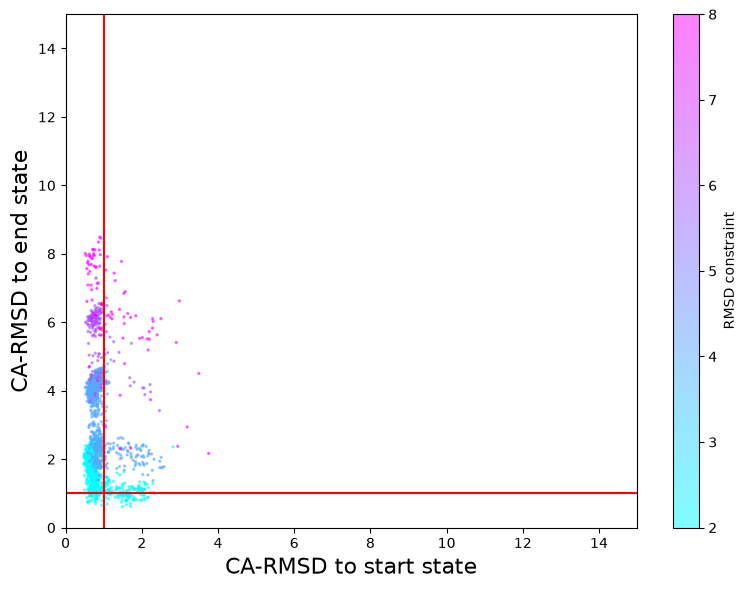

35 of 2094 pass multi-state design filters


In [540]:
# RMSD cutoff

# figure
plt.figure(figsize=(8, 6))

# make custom cmap for plddt
norm = mcolors.TwoSlopeNorm(
    vmin=30,
    vcenter=90,
    vmax=100
)

# graph
plt.scatter(
    graph_df['rmsd_start'],
    graph_df['rmsd_end'],
    #c = graph_df['plddt'],
    #cmap = 'vanimo',
    #norm = norm,
    c = graph_df['rmsd_constraint'],
    cmap = 'cool',
    s = 2,
    alpha = 0.5
)

# axes
plt.colorbar(label = 'RMSD constraint')
plt.xlabel('CA-RMSD to start state', fontsize=16)
plt.ylabel('CA-RMSD to end state', fontsize=16)
plt.ylim(0, 15)
plt.xlim(plt.ylim())

# cutoff
plt.axhline(
    y = 1,
    color = 'red'
)
plt.axvline(
    x = 1,
    color = 'red'
)

# show
plt.tight_layout()
plt.show()

# print quick metrics
successes = len(graph_df[
    (graph_df['rmsd_start'] < 1) &
    (graph_df['rmsd_end'] < 1) &
    (graph_df['plddt'] > 90)
])
print(f'{successes} of {len(graph_df)} pass multi-state design filters')

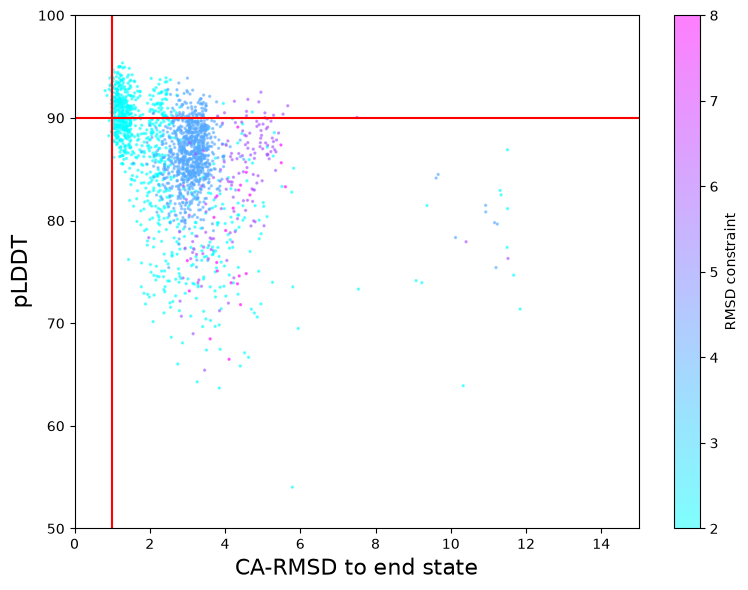

In [537]:
# RMSD to start/end state
rmsd = 'rmsd_end'
plt.figure(figsize=(8, 6))

# plot
plt.scatter(
    graph_df[rmsd],
    graph_df['plddt'],
    c = graph_df['rmsd_constraint'],
    cmap = 'cool',
    s = 2,
    alpha = 0.5
)

# axes
plt.colorbar(label='RMSD constraint')
plt.xlabel(f'CA-RMSD to {rmsd.split('_')[1]} state', fontsize=16)
plt.xlim(0, 15)
plt.ylabel('pLDDT', fontsize=16)
plt.ylim(50, 100)

# cutoffs
plt.axhline(
    y = 90,
    color = 'red'
)
plt.axvline(
    x = 1,
    color = 'red'
)

# show
plt.tight_layout()
plt.show()

#### Association with other scores

In [546]:
successes = ['5KPH_2_2_3_id1', '5KPH_2_2_3_id16', '5KPH_2_2_3_id20', '5KPH_2_2_3_id5', '5KPH_2_2_4_id14', '5KPH_2_2_4_id16', '5KPH_2_2_4_id23', '5KPH_2_2_4_id8', '5KPH_2_2_7_id16', '5KPH_2_2_7_id22', '5KPH_2_2_9_id11', '5KPH_2_2_9_id3', '5KPH_2_4_8_id6', '5KPH_2_6_5_id15', '5KPH_2_6_5_id17', '5KPH_2_6_5_id3', '5KPH_2_6_5_id9', '5KPH_2_6_6_id23', '5KPH_2_6_9_id14', '5KPH_2_8_3_id14']

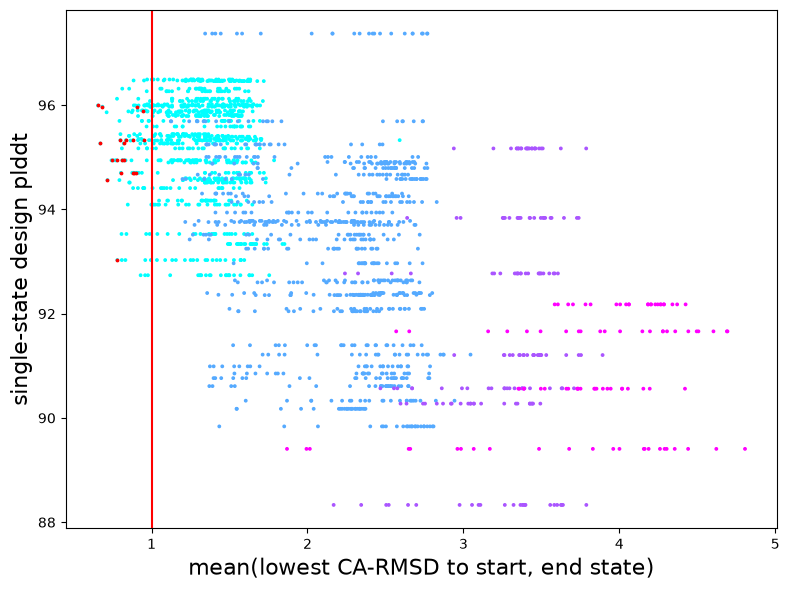

In [548]:
# single state design metrics
metric = 'plddt' #'plddt', 'rmsd'

plt.figure(figsize=(8, 6))
plt.scatter(
    np.mean(np.vstack([graph_df['rmsd_start'], graph_df['rmsd_end']]), axis=0),
    graph_df[f'single_state_{metric}'],
    s = 3,
    c = graph_df['rmsd_constraint'],
    cmap = 'cool'
)

# successes
if 'name' in graph_df.columns:
    graph_df = graph_df.set_index('name')
for success in successes:
    plt.scatter(
        [np.mean([graph_df.loc[success, 'rmsd_start'], graph_df.loc[success, 'rmsd_end']])], #type: ignore
        [graph_df.loc[success, f'single_state_{metric}']], #type: ignore
        s = 3,
        c = 'red'
    )


# cutoff
plt.axvline(
    x = 1,
    color = 'red'
)

# axes
plt.xlabel('mean(lowest CA-RMSD to start, end state)', fontsize=16)
plt.ylabel(f'single-state design {metric}', fontsize=16)
plt.tight_layout()
plt.show()

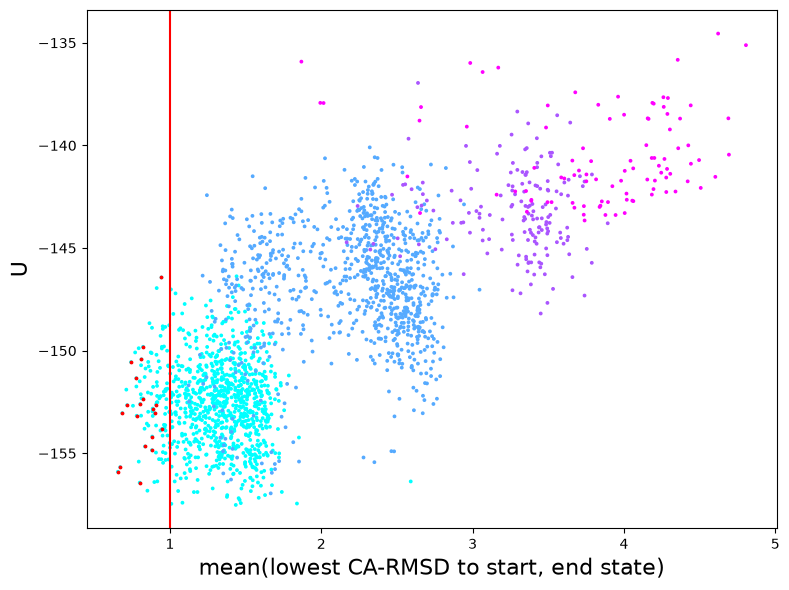

In [550]:
# sequence design metrics
metric = 'U' #'score' for MPNN, 'U' for caliby, '-PLL' for frame2seq

# plot
plt.figure(figsize=(8, 6))
plt.scatter(
    np.mean(np.vstack([graph_df['rmsd_start'], graph_df['rmsd_end']]), axis=0),
    graph_df[f'{metric}'],
    s = 3,
    c = graph_df['rmsd_constraint'],
    cmap = 'cool'
)

# success
if 'name' in graph_df.columns:
    graph_df = graph_df.set_index('name')
for success in successes:
    #graph_df = graph_df.set_index('name')
    plt.scatter(
        [np.mean([graph_df.loc[success, 'rmsd_start'], graph_df.loc[success, 'rmsd_end']])], #type: ignore
        [graph_df.loc[success, f'{metric}']], #type: ignore
        s = 3,
        c = 'red'
    )

# cutoff
plt.axvline(
    x = 1,
    color = 'red'
)

# axes
plt.xlabel('mean(lowest CA-RMSD to start, end state)', fontsize=16)
plt.ylabel(f'{metric}', fontsize=16)
plt.tight_layout()
plt.show()


#### Analyze filter passed

In [541]:
# get designs passing filter
data_unique_filtered = data_unique[
    (data_unique['rmsd_start'] < 1) & (data_unique['rmsd_end'] < 1)
    & (data_unique['plddt'] > 90)
]
print(f'{len(data_unique_filtered)} of {len(data_unique)} designs pass filter')

# get the predictions of those designs
data_filtered = data[
    data['name'].isin(data_unique_filtered['name'])
]

35 of 4110 designs pass filter


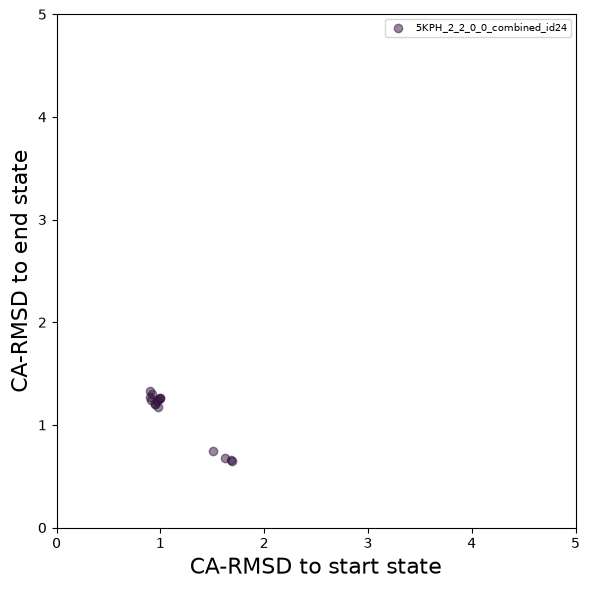

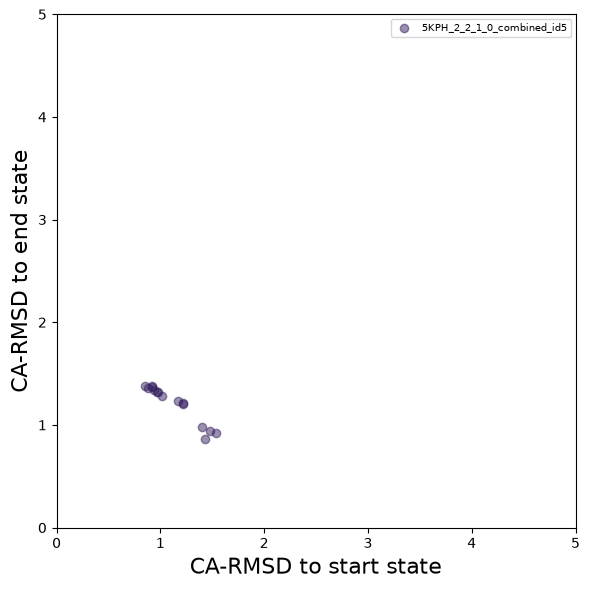

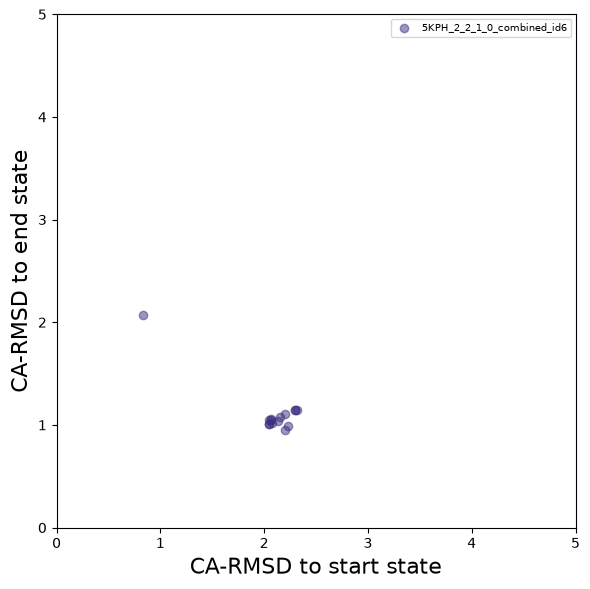

KeyboardInterrupt: 

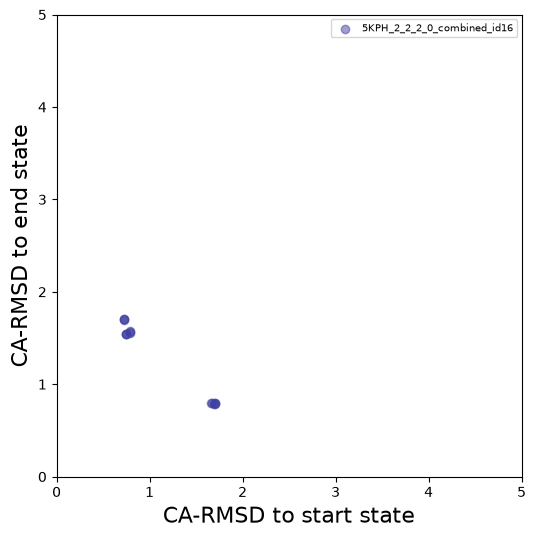

In [184]:
# check for predictions in between states

# plot---------------
# color
colors = iter(plt.colormaps['turbo'](np.linspace(0, 1, len(data_unique_filtered))))

# for each designed sequence
for name in data_unique_filtered['name']:
    df = data_filtered[data_filtered['name'] == name]
    plt.figure(figsize=(6, 6))
    plt.scatter(
        df['rmsd_start'],
        df['rmsd_end'],
        color = next(colors),
        label = name,
        alpha = 0.5
    )

    # axes
    plt.legend(loc='upper right', fontsize='x-small')
    plt.xlabel('CA-RMSD to start state', fontsize=16)
    plt.xlim(0, 5)
    plt.ylabel('CA-RMSD to end state', fontsize=16)
    plt.ylim(0, 5)
    plt.tight_layout()
    plt.show()

In [581]:
# filter out false positives (?)
def false_positive(row, eps=0.2, threshold=1.0):
    start = row['rmsd_start']
    end = row['rmsd_end']
    constraint = int(row['name'].split('_')[1])

    # shouldn't really be a problem if RMSD constraint > 2? since
    # should be beyond range of expected AF error?
    if constraint > 2: 
        return True
    elif start < threshold:
        return end > constraint - eps
    elif end < threshold:
        return start > constraint - eps
    else:
        return False

# filter out false positives
data_filtered = data_filtered[data_filtered.apply(false_positive, axis=1)]

# use this to re-filter designed sequences
temp = data_filtered.groupby('name', as_index=False).agg(
    {
        'rmsd_start': 'min',
        'rmsd_end': 'min',
        'plddt': 'max'
    }
)
temp = temp[
    (temp['rmsd_start'] < 1) & (temp['rmsd_end'] < 1)
    & (temp['plddt'] > 1)
]
print(f'{len(temp)} of {len(data_unique_filtered)} designs remain after false positives removed')
data_unique_filtered = data_unique_filtered[
    data_unique_filtered['name'].isin(temp['name'])
]

20 of 20 designs remain after false positives removed


In [543]:
print(list(data_unique_filtered['name']))

['5KPH_2_2_3_id1', '5KPH_2_2_3_id16', '5KPH_2_2_3_id20', '5KPH_2_2_3_id5', '5KPH_2_2_4_id14', '5KPH_2_2_4_id16', '5KPH_2_2_4_id23', '5KPH_2_2_4_id8', '5KPH_2_2_7_id16', '5KPH_2_2_7_id22', '5KPH_2_2_9_id11', '5KPH_2_2_9_id3', '5KPH_2_4_8_id6', '5KPH_2_6_5_id15', '5KPH_2_6_5_id17', '5KPH_2_6_5_id3', '5KPH_2_6_5_id9', '5KPH_2_6_6_id23', '5KPH_2_6_9_id14', '5KPH_2_8_3_id14']


In [544]:
# save data
save_prefix = '/wynton/home/rotation/geanhu/multi-state/notebooks/data'
print(f'Saving {save_name} ...')

Saving 5KPE-5KPH_caliby_multi-state_temp10-2 ...


In [545]:
# per-prediction data
data.to_csv(f'{save_prefix}/{save_name}_data.csv', index=False)

# per-backbone data
data_unique.to_csv(f'{save_prefix}/{save_name}_data_unique.csv', index=False)

# successful designs
seq_path_csv = f'{seq_path}/filtered_seqs.csv'
seqs = pd.read_csv(seq_path_csv)
seqs = seqs[seqs['id'].isin(data_unique_filtered['name'])]
assert len(seqs) == len(data_unique_filtered)
seqs.to_csv(f'{save_prefix}/{save_name}_designs.csv', index=False)

#### Pool all designs

In [ ]:
dfs_unique = {}
dfs = {}
#
unique_folder = '/wynton/home/rotation/geanhu/multi-state/notebooks/data/data_unique'
data_folder = '/wynton/home/rotation/geanhu/multi-state/notebooks/data/data'

# all csvs
for item in Path(unique_folder).iterdir():
    if item.suffix == '.csv':
        # load
        dfs_unique[item.stem.split('_data')[0]] = pd.read_csv(str(item))
for item in Path(data_folder).iterdir():
    if item.suffix == '.csv':
        # load
        dfs[item.stem.split('_data')[0]] = pd.read_csv(str(item))

# merge
df_unique = (
    pd.concat(dfs_unique, names=['parameters']).reset_index(level='parameters').reset_index(drop=True)
)
df = (
    pd.concat(dfs, names=['parameters']).reset_index(level='parameters').reset_index(drop=True)
)

In [614]:
# add columns for params
df_unique['backbone'] = df_unique['parameters'].apply(
    lambda param: 'rfd' if ('refined' in param) else 'chroma'
).astype('category')
df_unique['seq_model'] = df_unique['parameters'].apply(
    lambda param: 'caliby' if ('caliby' in param) else 'mpnn'
).astype('category')

In [675]:
# filter structure
structure = '5KPH'
graph_df = df_unique[df_unique['name'].str.contains(structure)]
graph_df_data = df[df['name'].str.contains(structure)]

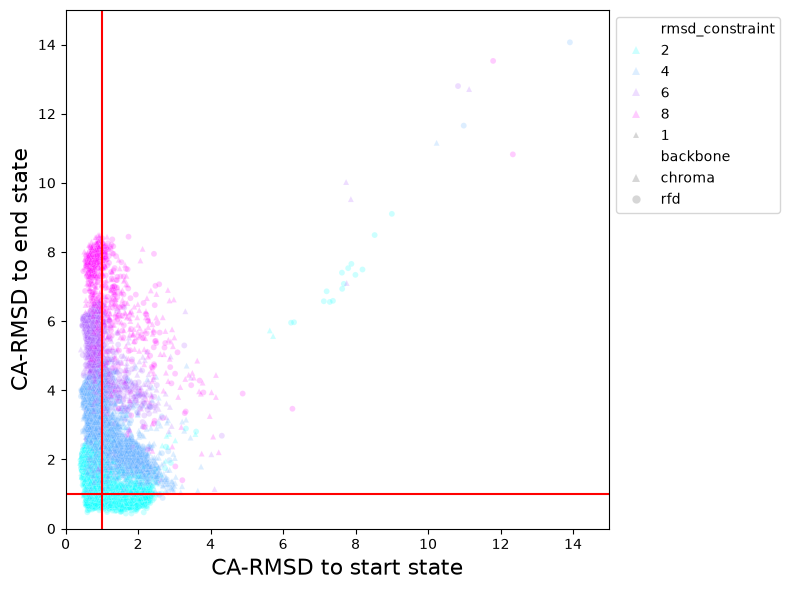

In [676]:
# plot cutoffs

# figure
plt.figure(figsize=(8, 6))
sns.scatterplot(
    # plot rmsd x y
    x = graph_df['rmsd_start'],
    y = graph_df['rmsd_end'],

    # color by RMSD constraint
    hue = graph_df['rmsd_constraint'],
    palette = 'cool',

    # style by seq design model
    style = graph_df['backbone'],
    markers={
        'rfd': 'o',
        'chroma': '^',
    },

    # constant
    size = 1,
    alpha = 0.2
)

# axes
plt.xlabel('CA-RMSD to start state', fontsize=16)
plt.ylabel('CA-RMSD to end state', fontsize=16)
plt.ylim(0, 15)
plt.xlim(plt.ylim())

# cutoff
plt.axhline(
    y = 1,
    color = 'red'
)
plt.axvline(
    x = 1,
    color = 'red'
)

# show
plt.legend(
    loc = 'upper left',
    bbox_to_anchor = (1, 1)
)
plt.tight_layout()
plt.show()

In [678]:
# filtering
successes = (graph_df[
    (graph_df['rmsd_start'] < 1) &
    (graph_df['rmsd_end'] < 1) &
    (graph_df['plddt'] > 90)
])

#successes = successes[successes.apply(lambda row: false_positive(row, eps=0.2, threshold=1), axis=1)]
print(f'{len(successes)} of {len(graph_df)} pass multi-state design filters')

'''
# plot to double check
if len(successes) < 50:
    # color
    colors = plt.colormaps['turbo'](np.linspace(0, 1, 10))

    # for each designed sequence
    for idx, (name, param) in enumerate(zip(successes['name'], successes['parameters'])):
        name_df = graph_df_data[
            (graph_df_data['name'] == name) &
            (graph_df_data['parameters'] == param)
        ]

        # plot
        plt.figure(figsize=(4, 4))
        plt.scatter(
            name_df['rmsd_start'],
            name_df['rmsd_end'],
            color = colors[idx%10],
            label = name,
            alpha = 0.5
        )

        # axes
        plt.legend(loc='upper right', fontsize='x-small')
        plt.xlabel('CA-RMSD to start state', fontsize=16)
        plt.xlim(0, 5)
        plt.ylabel('CA-RMSD to end state', fontsize=16)
        plt.ylim(0, 5)
        plt.tight_layout()
        plt.show()
'''

683 of 19283 pass multi-state design filters


"\n# plot to double check\nif len(successes) < 50:\n    # color\n    colors = plt.colormaps['turbo'](np.linspace(0, 1, 10))\n\n    # for each designed sequence\n    for idx, (name, param) in enumerate(zip(successes['name'], successes['parameters'])):\n        name_df = graph_df_data[\n            (graph_df_data['name'] == name) &\n            (graph_df_data['parameters'] == param)\n        ]\n\n        # plot\n        plt.figure(figsize=(4, 4))\n        plt.scatter(\n            name_df['rmsd_start'],\n            name_df['rmsd_end'],\n            color = colors[idx%10],\n            label = name,\n            alpha = 0.5\n        )\n\n        # axes\n        plt.legend(loc='upper right', fontsize='x-small')\n        plt.xlabel('CA-RMSD to start state', fontsize=16)\n        plt.xlim(0, 5)\n        plt.ylabel('CA-RMSD to end state', fontsize=16)\n        plt.ylim(0, 5)\n        plt.tight_layout()\n        plt.show()\n"

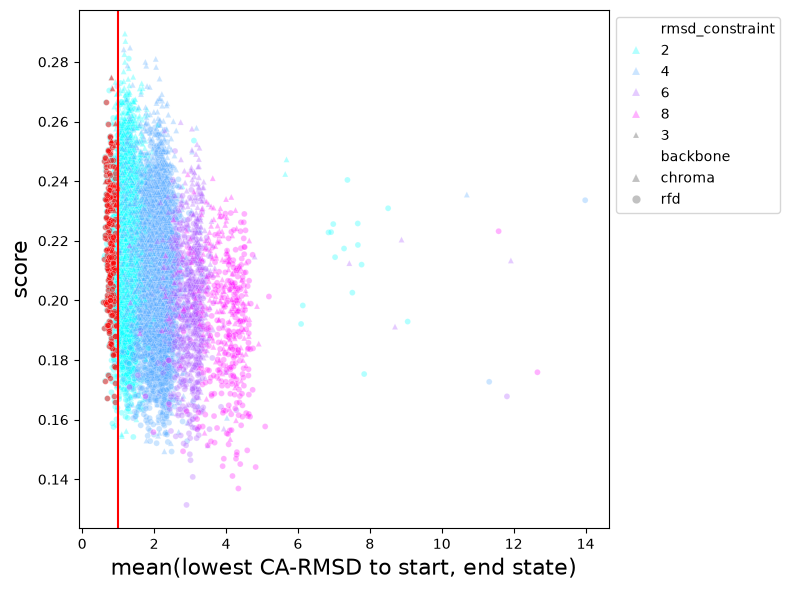

Spearman rho = -0.278, p=6.33e-200
R2 = 0.076


In [687]:
# other metrics
metric = 'score' #'plddt', 'rmsd'

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x = np.mean(np.vstack([graph_df['rmsd_start'], graph_df['rmsd_end']]), axis=0),
    y = graph_df[f'{metric}'],
    size = 3,
    hue = graph_df['rmsd_constraint'],
    palette = 'cool',
    style = graph_df['backbone'],
    markers={
        'rfd': 'o',
        'chroma': '^',
    },
    alpha = 0.3
)

# successes
for _, success in successes.iterrows():
    row = graph_df[
        (graph_df['name'] == success['name']) &
        (graph_df['parameters'] == success['parameters'])
    ]
    backbone = row['backbone'].values[0]
    sns.scatterplot(
        x = [np.mean([row['rmsd_start'].values[0], row['rmsd_end'].values[0]])], #type: ignore
        y = [row[f'{metric}'].values[0]], #type: ignore
        size = 3,
        color = 'red',
        marker= ('o' if (backbone == 'rfd') else '^'),
        legend = False,
        alpha = 0.5
    )


# cutoff
plt.axvline(
    x = 1,
    color = 'red'
)

# axes
plt.legend(
    loc = 'upper left',
    bbox_to_anchor = (1, 1)
)
plt.xlabel('mean(lowest CA-RMSD to start, end state)', fontsize=16)
plt.ylabel(f'{metric}', fontsize=16)
if metric == 'single_state_rmsd':
    plt.ylim(0, 4)
elif metric == 'single_state_plddt':
    plt.ylim(85, 100)
plt.tight_layout()
plt.show()


# testing
x = np.mean(np.vstack([graph_df['rmsd_start'], graph_df['rmsd_end']]), axis=0)
y = graph_df[f'{metric}']
x = x[~np.isnan(y)]
y = y[~np.isnan(y)]

# spearman
rho, p = spearmanr(x, y)
print(f'Spearman rho = {rho:.3f}, p={p:.3g}')
# r2
res = linregress(x, y)
print(f'R2 = {res.rvalue**2:.3f}')


#### Export designs & structures

In [24]:
seq_info = pd.read_csv('/wynton/home/rotation/geanhu/multi-state/notebooks/data/designs/5KPE.csv', index_col=0)
seq_info = seq_info.rename(
    columns={
        seq_info.columns[0]: 'parameters',
        seq_info.columns[1]: 'id'
    }
)

In [ ]:
# open designs
design_path = '/wynton/home/rotation/geanhu/multi-state/notebooks/data/designs'
dfs = {}
#
# all csvs
for item in Path(design_path).iterdir():
    if item.suffix == '.csv' and (not item.stem == '5KPE'):
        # load
        dfs[item.stem.split('_designs')[0]] = pd.read_csv(str(item))

# merge
df = (
    pd.concat(dfs, names=['parameters']).reset_index(level='parameters').reset_index(drop=True)
)

# add 5KPE designs
df = (
    pd.concat([
        df, seq_info[['parameters', 'id']]
    ])
)
df = df.reset_index()
df.to_csv(f'{design_path}/designs.csv')


In [80]:
# load
design_path = '/wynton/home/rotation/geanhu/multi-state/notebooks/data/designs'
df = pd.read_csv(f'{design_path}/designs.csv')

In [43]:
# open all predictions
data_path = '/wynton/home/rotation/geanhu/multi-state/notebooks/data/data'
data_dfs = {}
#
for item in Path(data_path).iterdir():
    if item.suffix == '.csv':
        # load
        data_dfs[item.stem.split('_data')[0]] = pd.read_csv(str(item))

# merge
data_df = (
    pd.concat(data_dfs, names=['parameters']).reset_index(level='parameters').reset_index(drop=True)
)

In [81]:
# store items in prediction folders once
prediction_base = '/wynton/home/rotation/geanhu/multi-state/data/colabfold-output'
prediction_folders = {}
for param in tqdm(np.unique(df['parameters'])):
    prediction_folder = Path(
        f'{prediction_base}',
        param.split('_temp')[0].lstrip(),
        f'temp{param.split('_temp')[1]}'
    )
    prediction_folders[prediction_folder] = [
        item for item in prediction_folder.iterdir() if item.suffix == '.pdb'
    ]

100%|█████████████████████████████████| 10/10 [00:54<00:00,  5.45s/it]


In [94]:
# collect into folder
export_folder = '/wynton/home/rotation/geanhu/multi-state/data/misc/hits-export'

# save for each design
for idx, row in tqdm(df.iterrows(), total=df.shape[0]):

    # create folder
    save_folder = Path(export_folder, f'design{idx}')
    save_folder.mkdir(exist_ok=True)

    # start
    if row['id'].startswith('5KPH'):
        source = f'/wynton/home/rotation/geanhu/multi-state/data/string-sampling/start-states/5KPH.pdb'
        assert Path(source).exists(), source
        #
        shutil.copy(source, f'{save_folder}/start.pdb')
    else:
        source = f'/wynton/home/rotation/geanhu/multi-state/data/string-sampling/start-states/5KPE.pdb'
        assert Path(source).exists(), source
        #
        shutil.copy(source, f'{save_folder}/start.pdb')

    # end
    if not 'refined' in row['parameters']:
        end_name = '_'.join(row['id'].split('_')[:4])
        source = f'/wynton/home/rotation/geanhu/multi-state/data/string-sampling/end-states/{end_name}.pdb'
    else:
        if 'caliby' in row['parameters']:
            end_name = f'{'_'.join(row['id'].split('_')[:4])}_0'.lstrip()
        else:
            end_name = '_'.join(row['id'].split('_')[:5]).lstrip()
        source = f'/wynton/home/rotation/geanhu/multi-state/data/diffusion-output/5KPE-5KPH/pdb/{end_name}.pdb'
    assert Path(source).exists(), source
    shutil.copy(source, f'{save_folder}/end.pdb')

    # preds
    # path where predictions are stored
    prediction_base = '/wynton/home/rotation/geanhu/multi-state/data/colabfold-output'
    prediction_folder = Path(
        f'{prediction_base}',
        row['parameters'].split('_temp')[0].lstrip(),
        f'temp{row['parameters'].split('_temp')[1]}'
    )
    prediction_paths = [str(item) for item in prediction_folders[prediction_folder] if (item.stem.startswith(f'{row['id']}_'))]
    assert len(prediction_paths) > 0 and len(prediction_paths) <= 15, prediction_paths

    # find corresponding data for predictions
    data_design = data_df[
        (data_df['parameters'] == row['parameters']) &
        (data_df['name'] == row['id'])
    ]
    assert len(data_design) > 0, f'{prediction_paths}\n{len(prediction_paths)}\n{data_design}'

    # sort by RMSD
    rmsds = []
    remove_list = []
    for idx, itempath in enumerate(prediction_paths):
        # find corresponding data
        seed = int(itempath.split('_seed_')[1][:3])
        model = int(itempath.split('model_')[1][0])
        data_item = data_design[
            (data_design['seed'] == seed) &
            (data_design['model'] == model)
        ]

        # duplicates
        if len(data_item) == 2:
            data_item = data_item.sort_values(by='rmsd_start').iloc[[0]]
        assert len(data_item) == 1, data_item

        rmsd = float(data_item['rmsd_start'].values[0])
        #
        if rmsd < 10.0:
            rmsds.append(rmsd)
        else:
            remove_list.append(idx)

    # remove preds with no RMSD calcs
    prediction_paths = [item for idx, item in enumerate(prediction_paths) if not (idx in remove_list)]
    assert len(prediction_paths) == len(rmsds)

    # sort
    rmsd_order = np.argsort(rmsds)
    prediction_paths = np.array(prediction_paths)[rmsd_order]

    # copy
    for idx, itempath in enumerate(prediction_paths):
        shutil.copy(itempath, f'{save_folder}/pred{idx}.pdb')
    

100%|██████████████████████████████████████████████████████████████████████████████████████| 436/436 [10:43<00:00,  1.47s/it]


In [120]:
df['id'] = df.apply(
    lambda row: f'design{row.name}',
    axis=1
)
df.to_csv(f'{design_path}/design-seqs.csv', index=False)

In [118]:
df

,id,sequence
0,design0,SEEELLKKAADLVVKKLKELFPDAKAEVLSVTVEGDTVYVTVKLTQ...
1,design1,SEEELLEKAAKKVEEELKKLYPDGEFKIESVRVEGNTIYVTVRLTL...
2,design2,SLEELLERARRLALEALRRLFPDATVTLESVEVEGDTVRVTARVEQ...
3,design3,SLEQLQAQAAQLAAAALRKLYPDAEVELLSVEVEGDALVVRVRLTE...
4,design4,SLQEMLERASELVKEKLKELFPDAEVELLSVEVSGNRITAQALLKE...
...,...,...
431,design431,DPLERGRAAGEAIVELLKDINNPEALQRLKELLTPEVAERFIKYAE...
432,design432,DPLERARRAGEAIVEAFKDINNKEALEYLKRVLSPEVAERLIKFIE...
433,design433,DPLERGREVAEAIVESFKDIENEEALETLRKYLSPEVADELIKFIE...
434,design434,DPLEEAERLGKAFIEALKDISNPEAVERLREIATPEVVERLLAFAK...
